# Lab 12 – Data Visualization

**Course:** IT 2012 – Unstructured Data  
**Dataset:** ArXiv AI-Detection Research Papers (`data/processed/cleaned/cleaned_data.csv`)

This notebook demonstrates all static (matplotlib/seaborn) and interactive (Plotly) charts,
then runs the automated chart generator and documents the visualization choices.

In [4]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../'))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Create output directories
STATIC_OUT      = Path('../outputs/visualizations/static')
INTERACTIVE_OUT = Path('../outputs/visualizations/interactive')
STATIC_OUT.mkdir(parents=True, exist_ok=True)
INTERACTIVE_OUT.mkdir(parents=True, exist_ok=True)

# Load cleaned dataset
df = pd.read_csv('../data/processed/cleaned/cleaned_data.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (50, 12)


,paper_id,title,authors,abstract,published_date,primary_category,all_categories,pdf_url,citation_count,relevance_score,language,published_year
0,2605.00924,Styleshield: Exposing The Fragility Of Aigc De...,Guantian Zheng,AI-generated content (AIGC) detectors are incr...,2026-04-30,cs.LG,cs.LG|cs.AI,https://arxiv.org/pdf/2605.00924,81,0.5557,en,2026
1,2604.26990,Ucsc-Nlp At Semeval-2026 Task 13: Multi-View G...,Kargi Chauhan; Sadiba Nusrat Nur,With the rapid growth of large language models...,2026-04-28,cs.SE,cs.SE,https://arxiv.org/pdf/2604.26990,94,0.6375,en,2026
2,2604.25370,Gpt-Image-2 In The Wild: A Twitter Dataset Of ...,Kidus Zewde; Simiao Ren; Xingyu Shen; Jenny Wu...,The release of GPT-image-2 by OpenAI marks a w...,2026-04-28,cs.CV,cs.CV|cs.AI,https://arxiv.org/pdf/2604.25370,28,0.5698,en,2026


---
## Part 3 – Static Bar and Line Charts with Matplotlib

### 3.1 Top 10 Papers by Citation Count – Horizontal Bar Chart

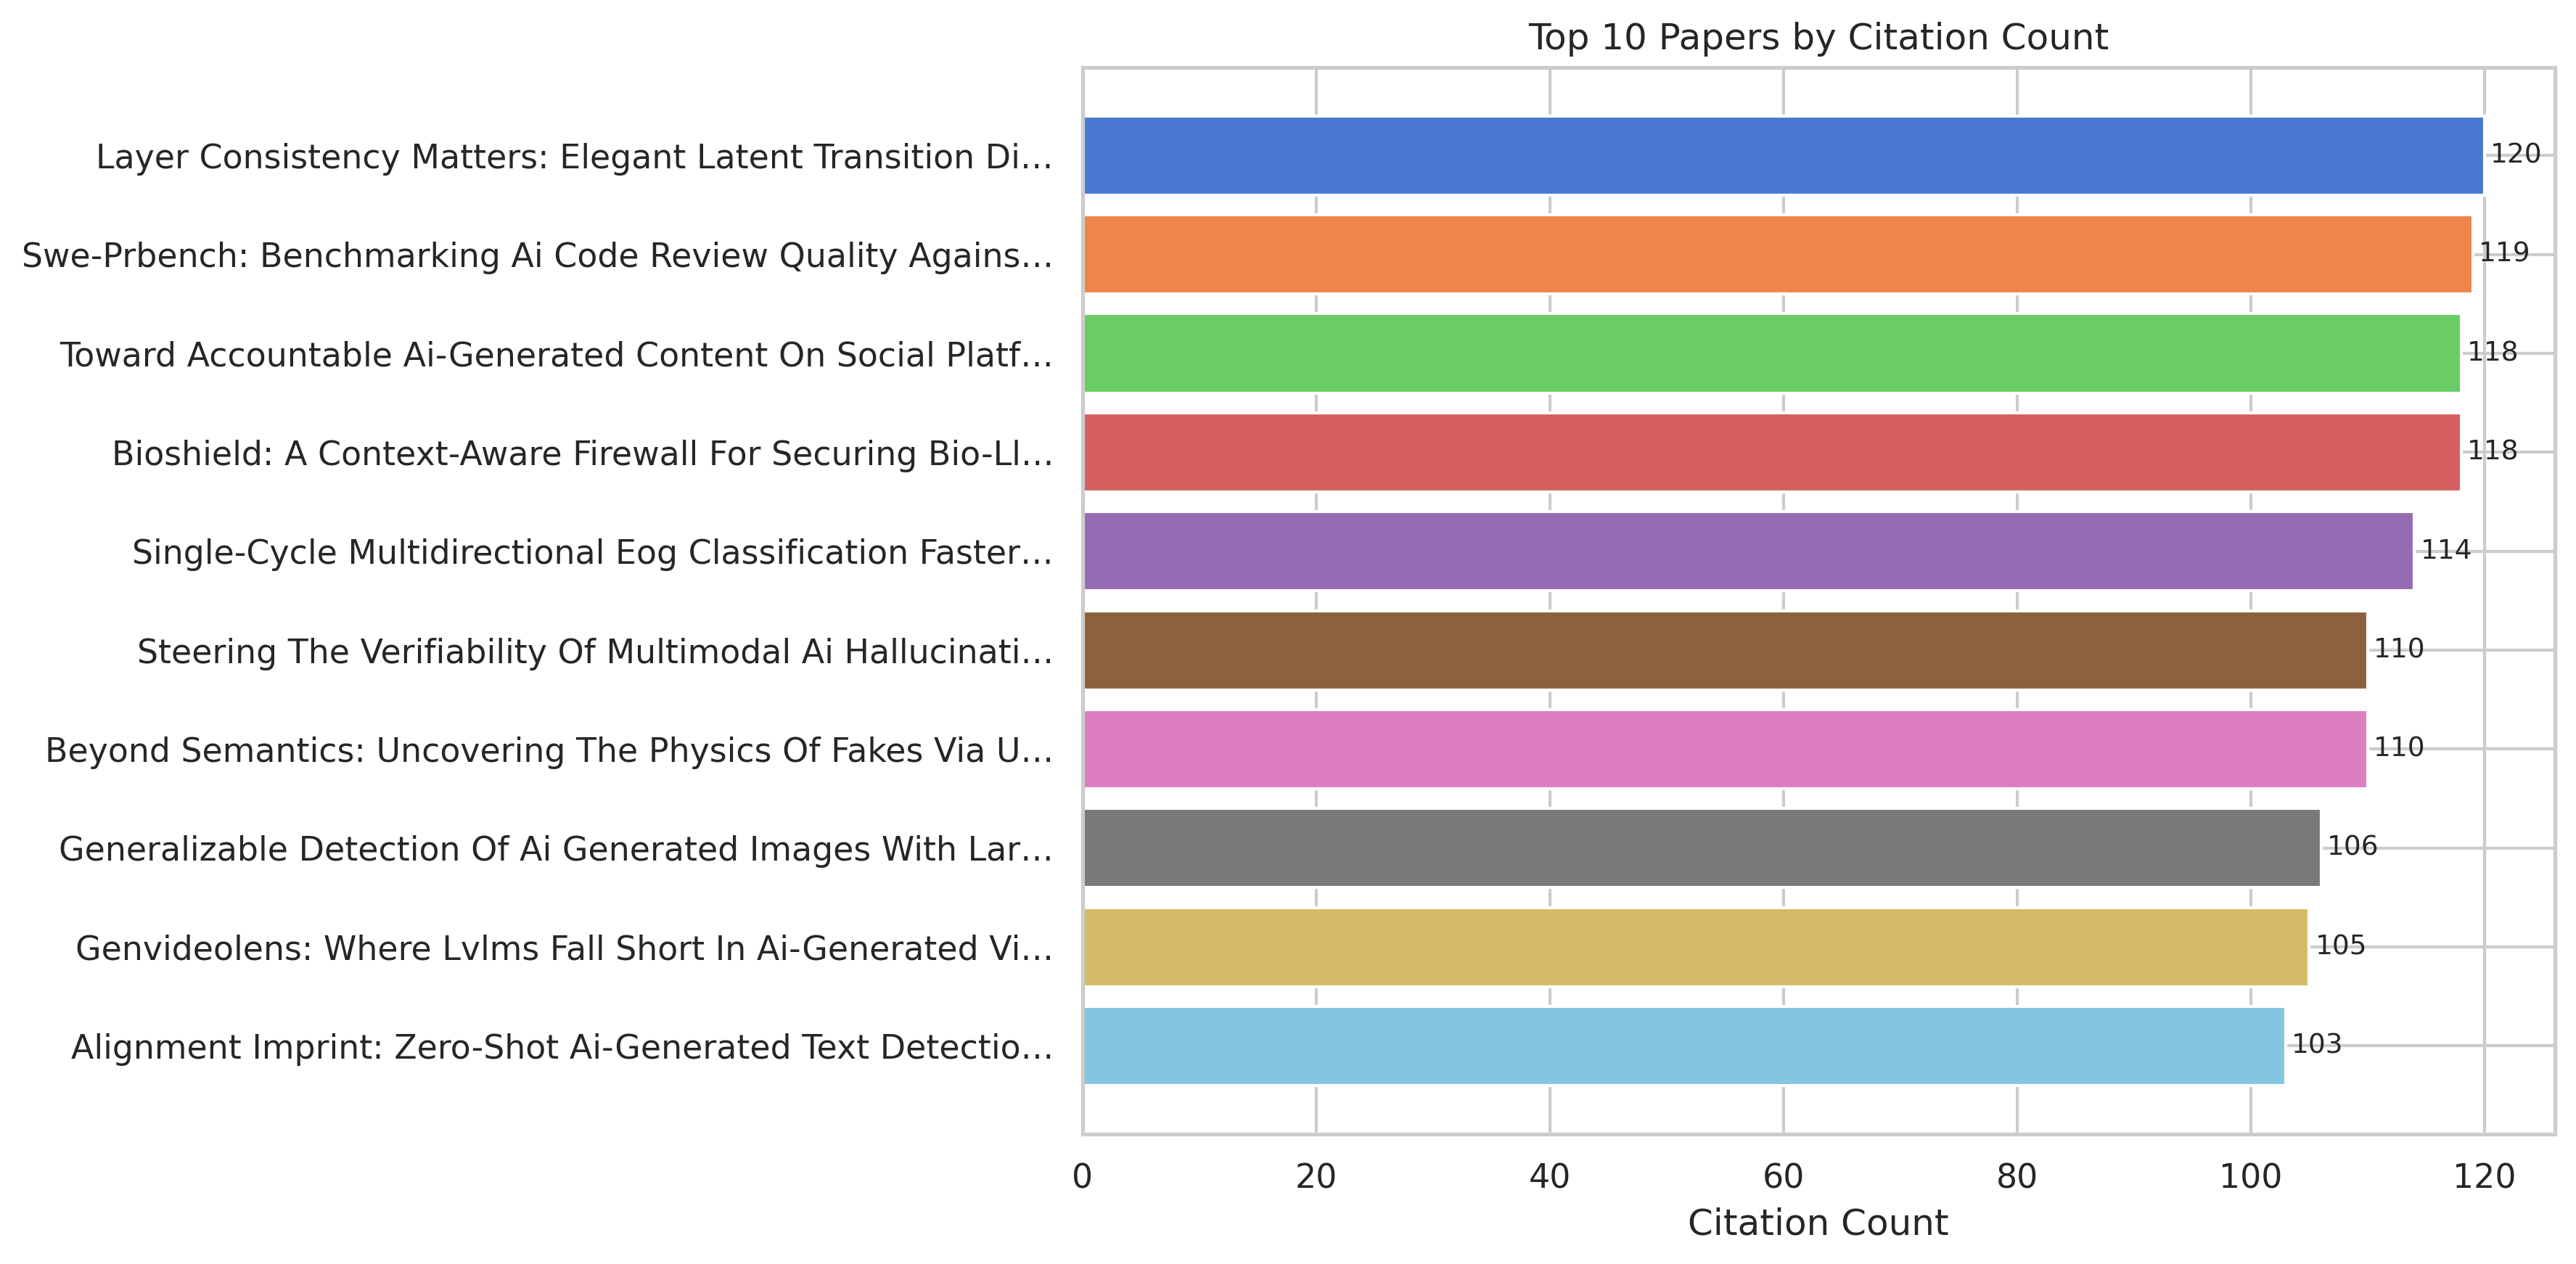

In [5]:
from src.visualization.static_charts import plot_top10_by_citations
plot_top10_by_citations(df, STATIC_OUT)
from IPython.display import Image
Image(str(STATIC_OUT / 'top10_by_citations.png'))

**Chart choice:** A horizontal bar chart is used because the category labels (paper titles) are
long strings that read more naturally left-to-right. Inline value annotations remove the need
to read the x-axis, keeping data-ink ratio high (Tufte principle).

### 3.2 Average Relevance Over Years – Dual-Axis Line Chart

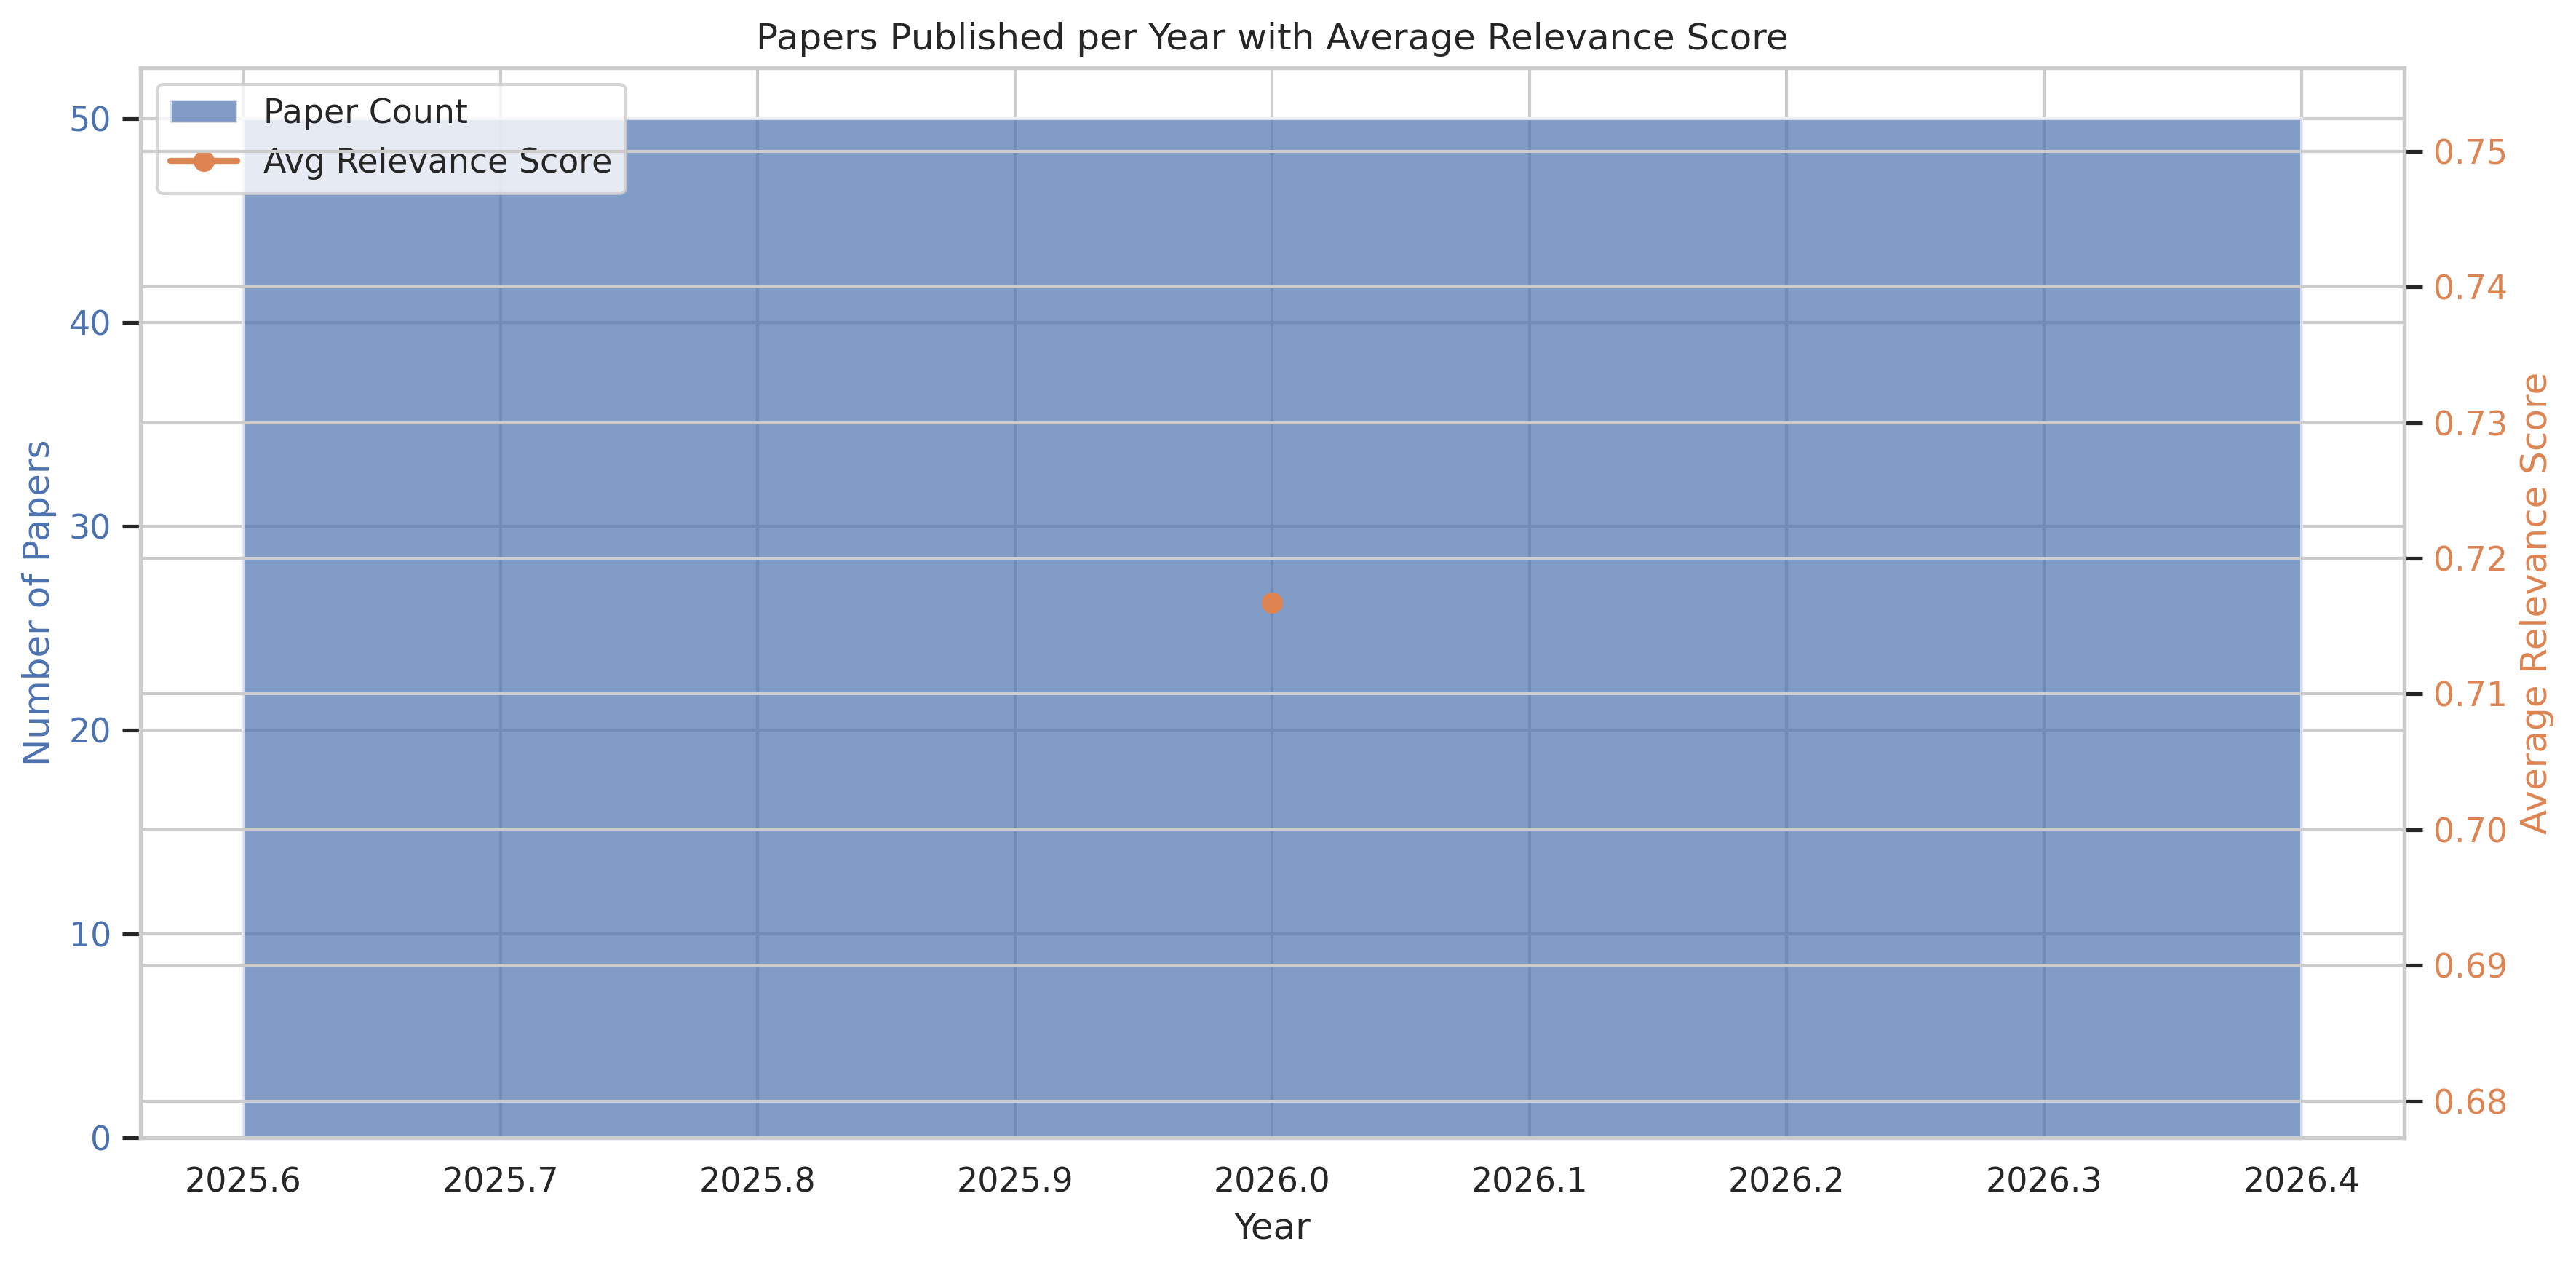

In [6]:
from src.visualization.static_charts import plot_papers_per_year
plot_papers_per_year(df, STATIC_OUT)
Image(str(STATIC_OUT / 'papers_per_year.png'))

**Chart choice:** A dual-axis chart overlays two differently-scaled series (volume and quality)
on a shared time axis. Bars encode count (discrete quantity); a line encodes the continuous
relevance trend. `ax.twinx()` avoids a second figure while keeping both scales readable.

---
## Part 4 – Statistical Charts with Seaborn

### 4.1 Citation Distribution – Histogram

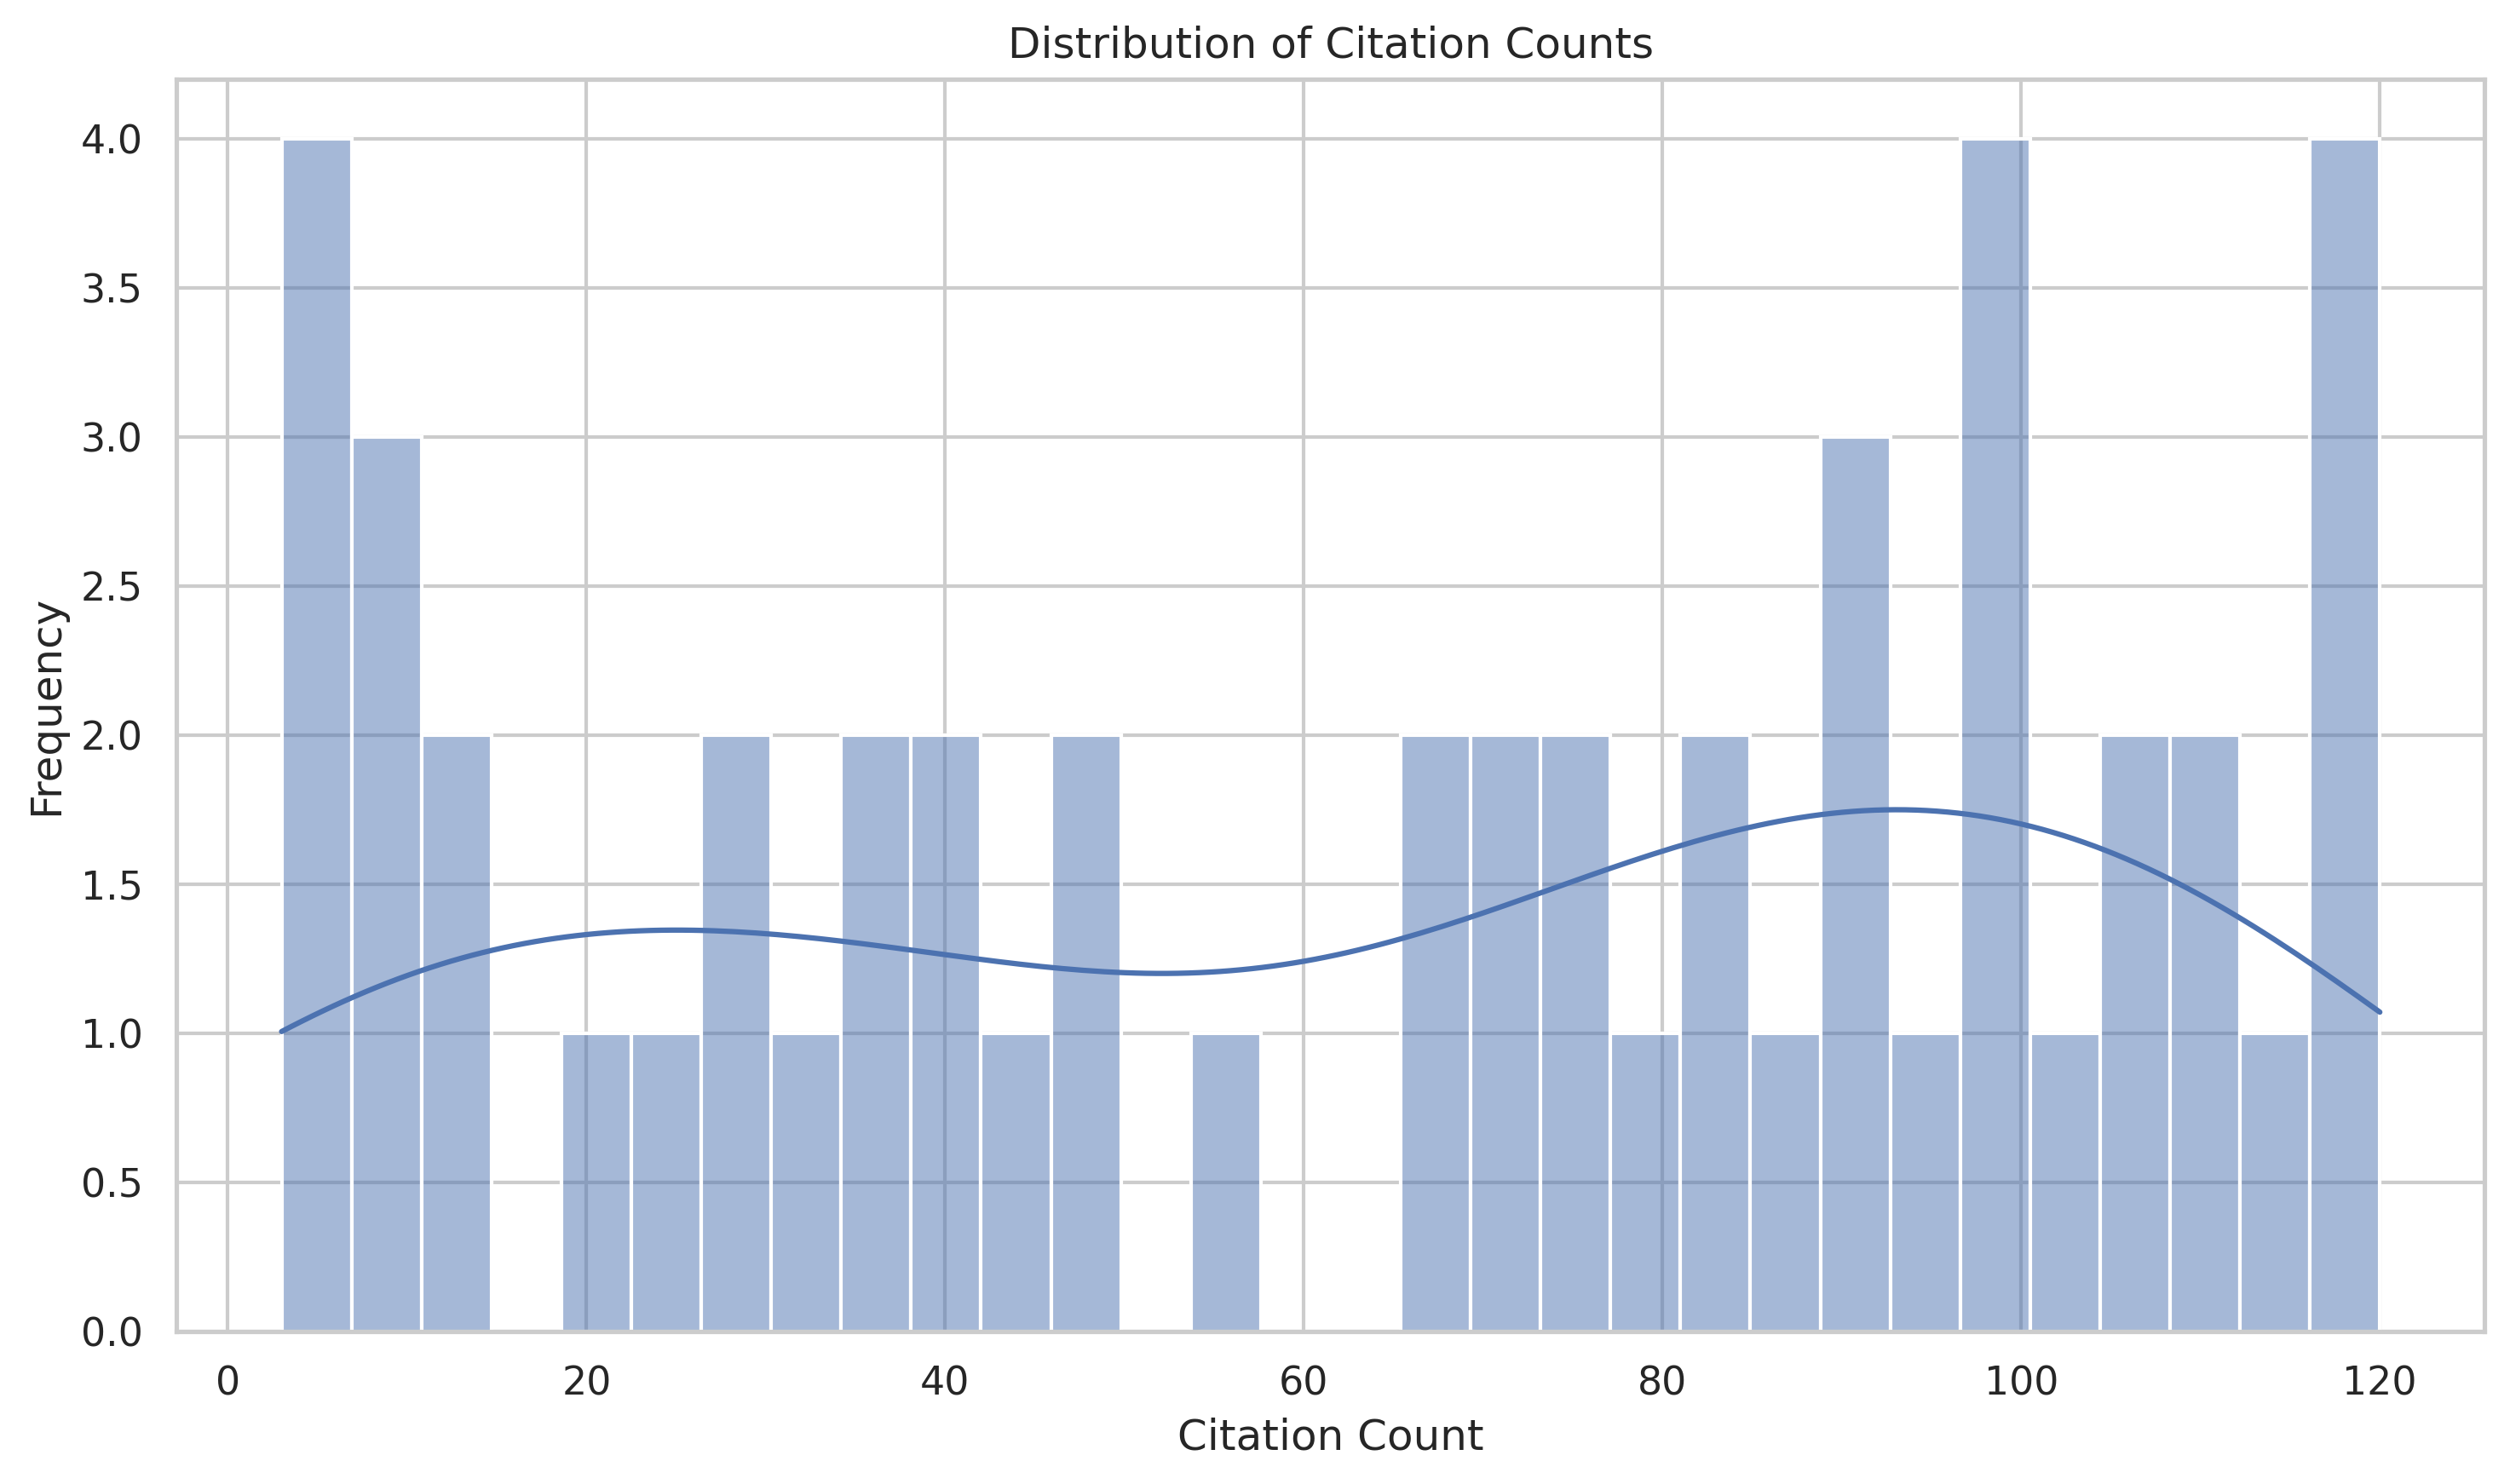

In [7]:
from src.visualization.static_charts import plot_citation_distribution
plot_citation_distribution(df, STATIC_OUT)
Image(str(STATIC_OUT / 'citation_distribution.png'))

**Chart choice:** A histogram with KDE overlay shows the full shape of the citation
distribution — whether it is skewed, bimodal, or has outliers. This is the correct choice
for a single continuous variable (Tufte: show the data, not a summary).

### 4.2 Citations by Category – Box Plot

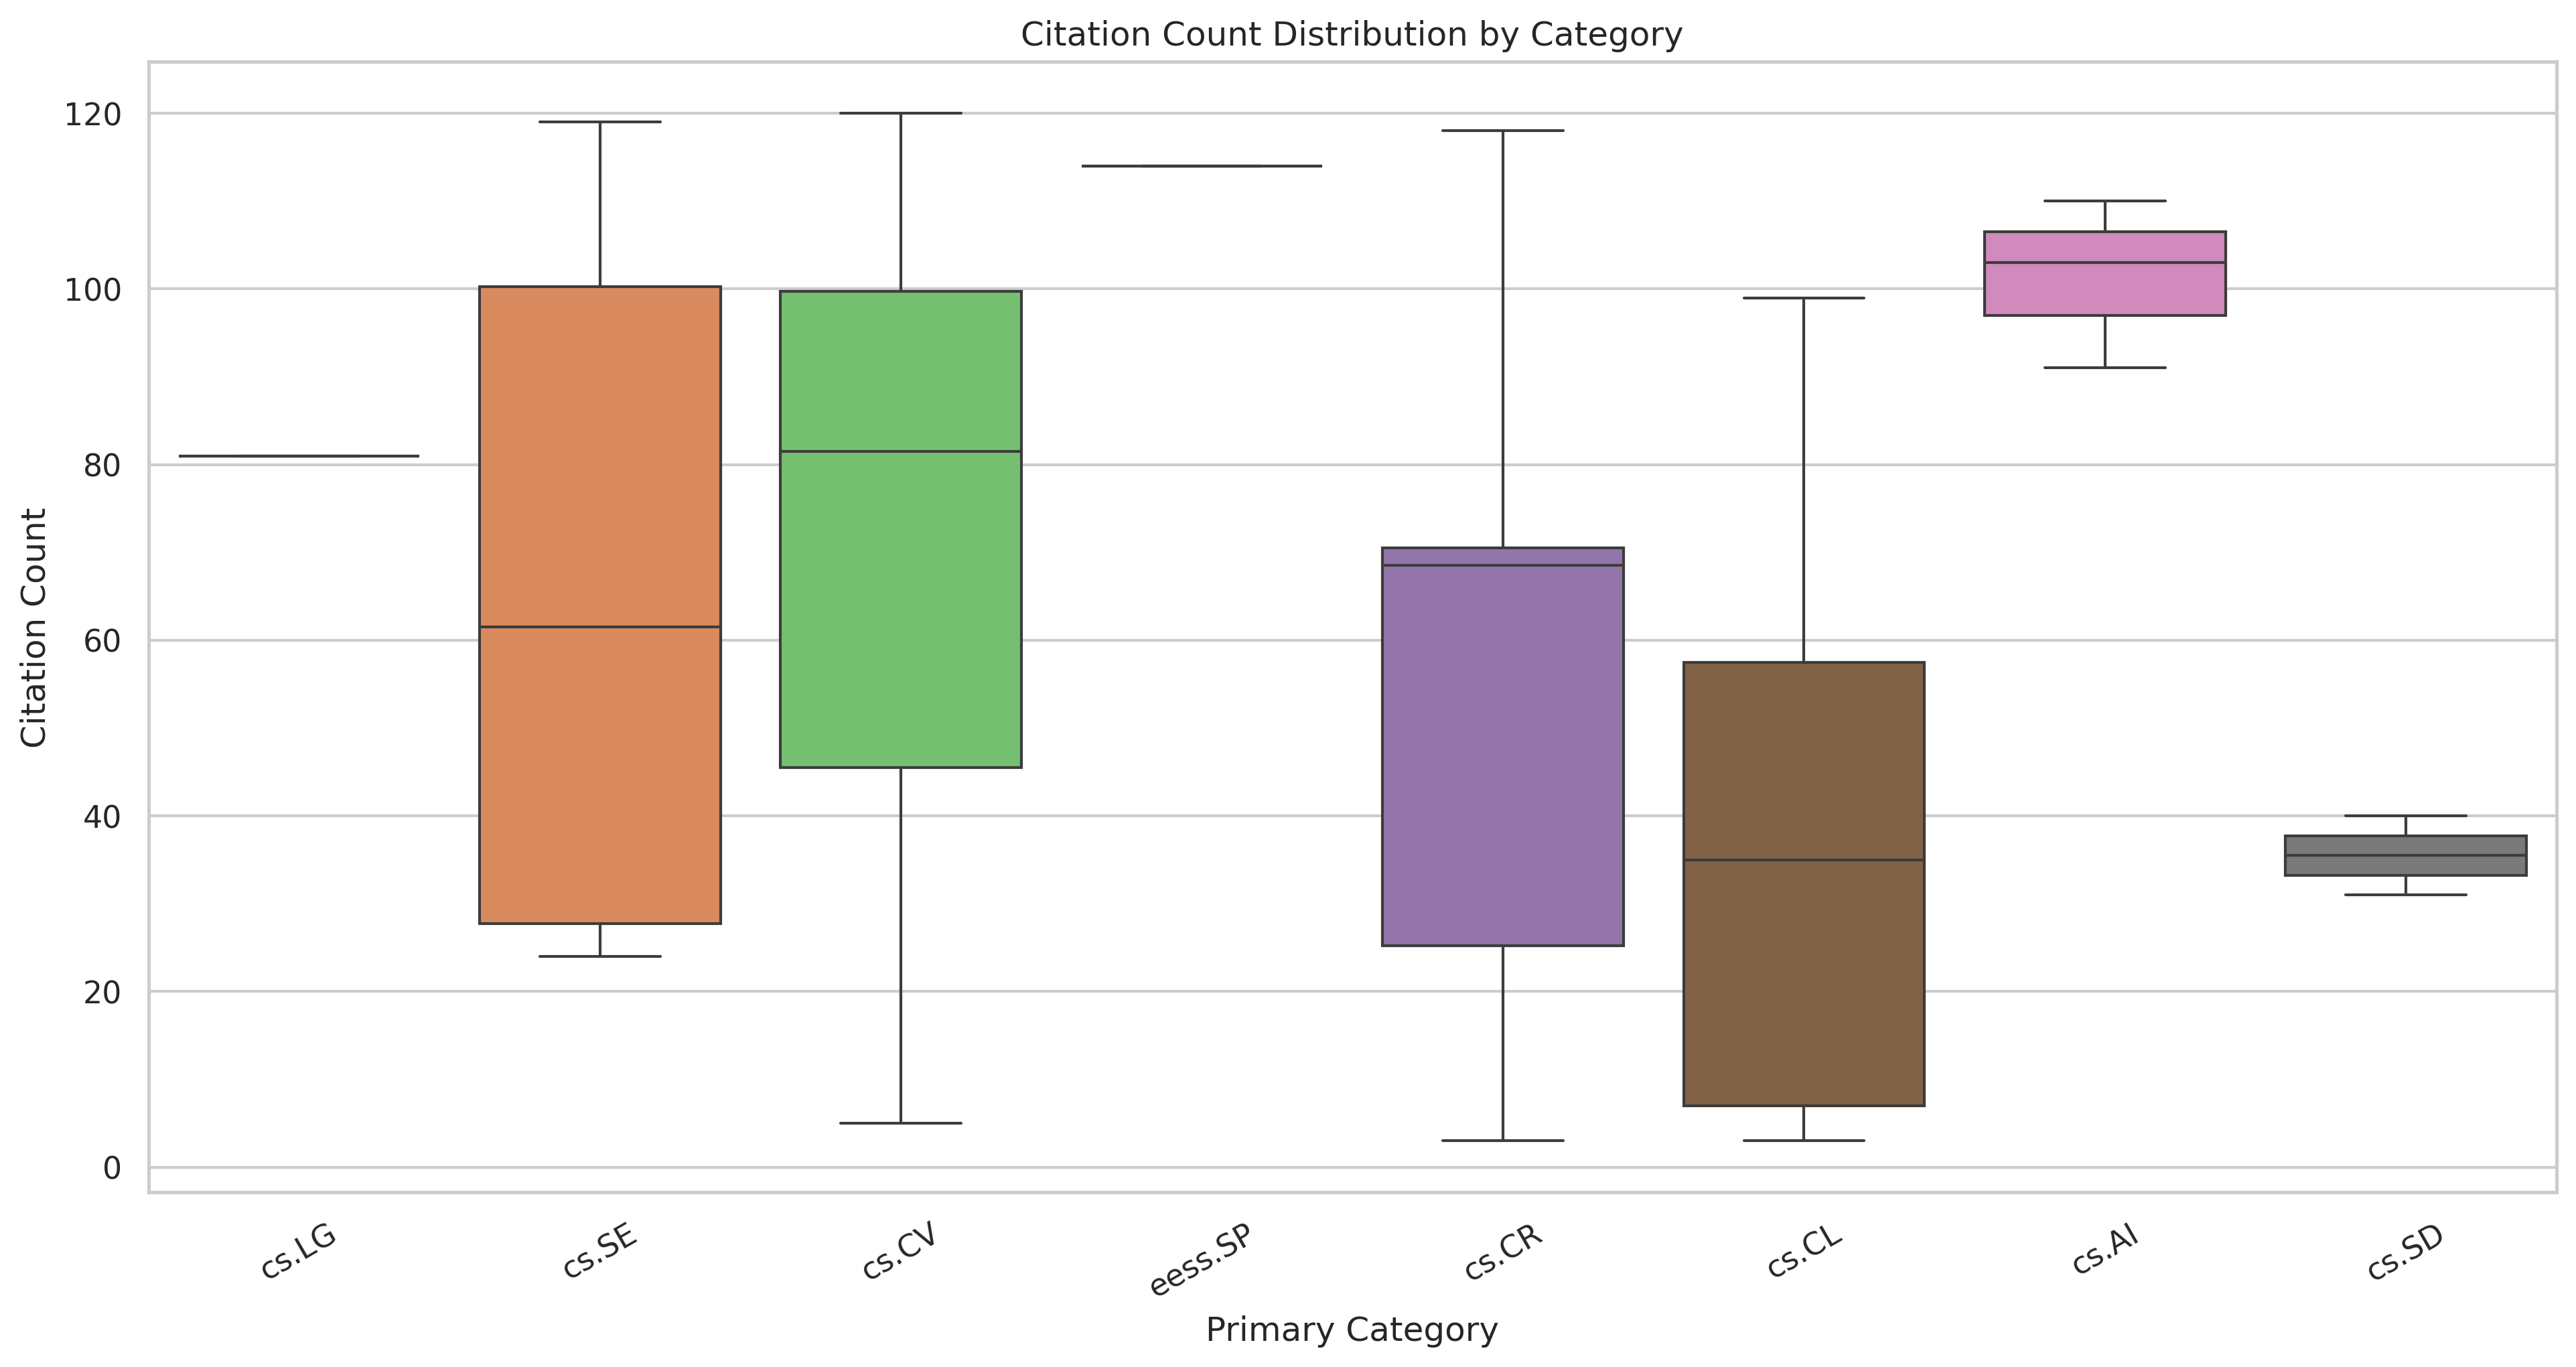

In [8]:
from src.visualization.static_charts import plot_citations_by_category
plot_citations_by_category(df, STATIC_OUT)
Image(str(STATIC_OUT / 'citations_by_category.png'))

**Chart choice:** A box plot compares distributions across multiple groups simultaneously,
exposing median, IQR, and outliers in each category. This is the ideal chart for the question
"how do citation counts differ by category?"

### 4.3 Relevance vs Citations – Scatter Plot

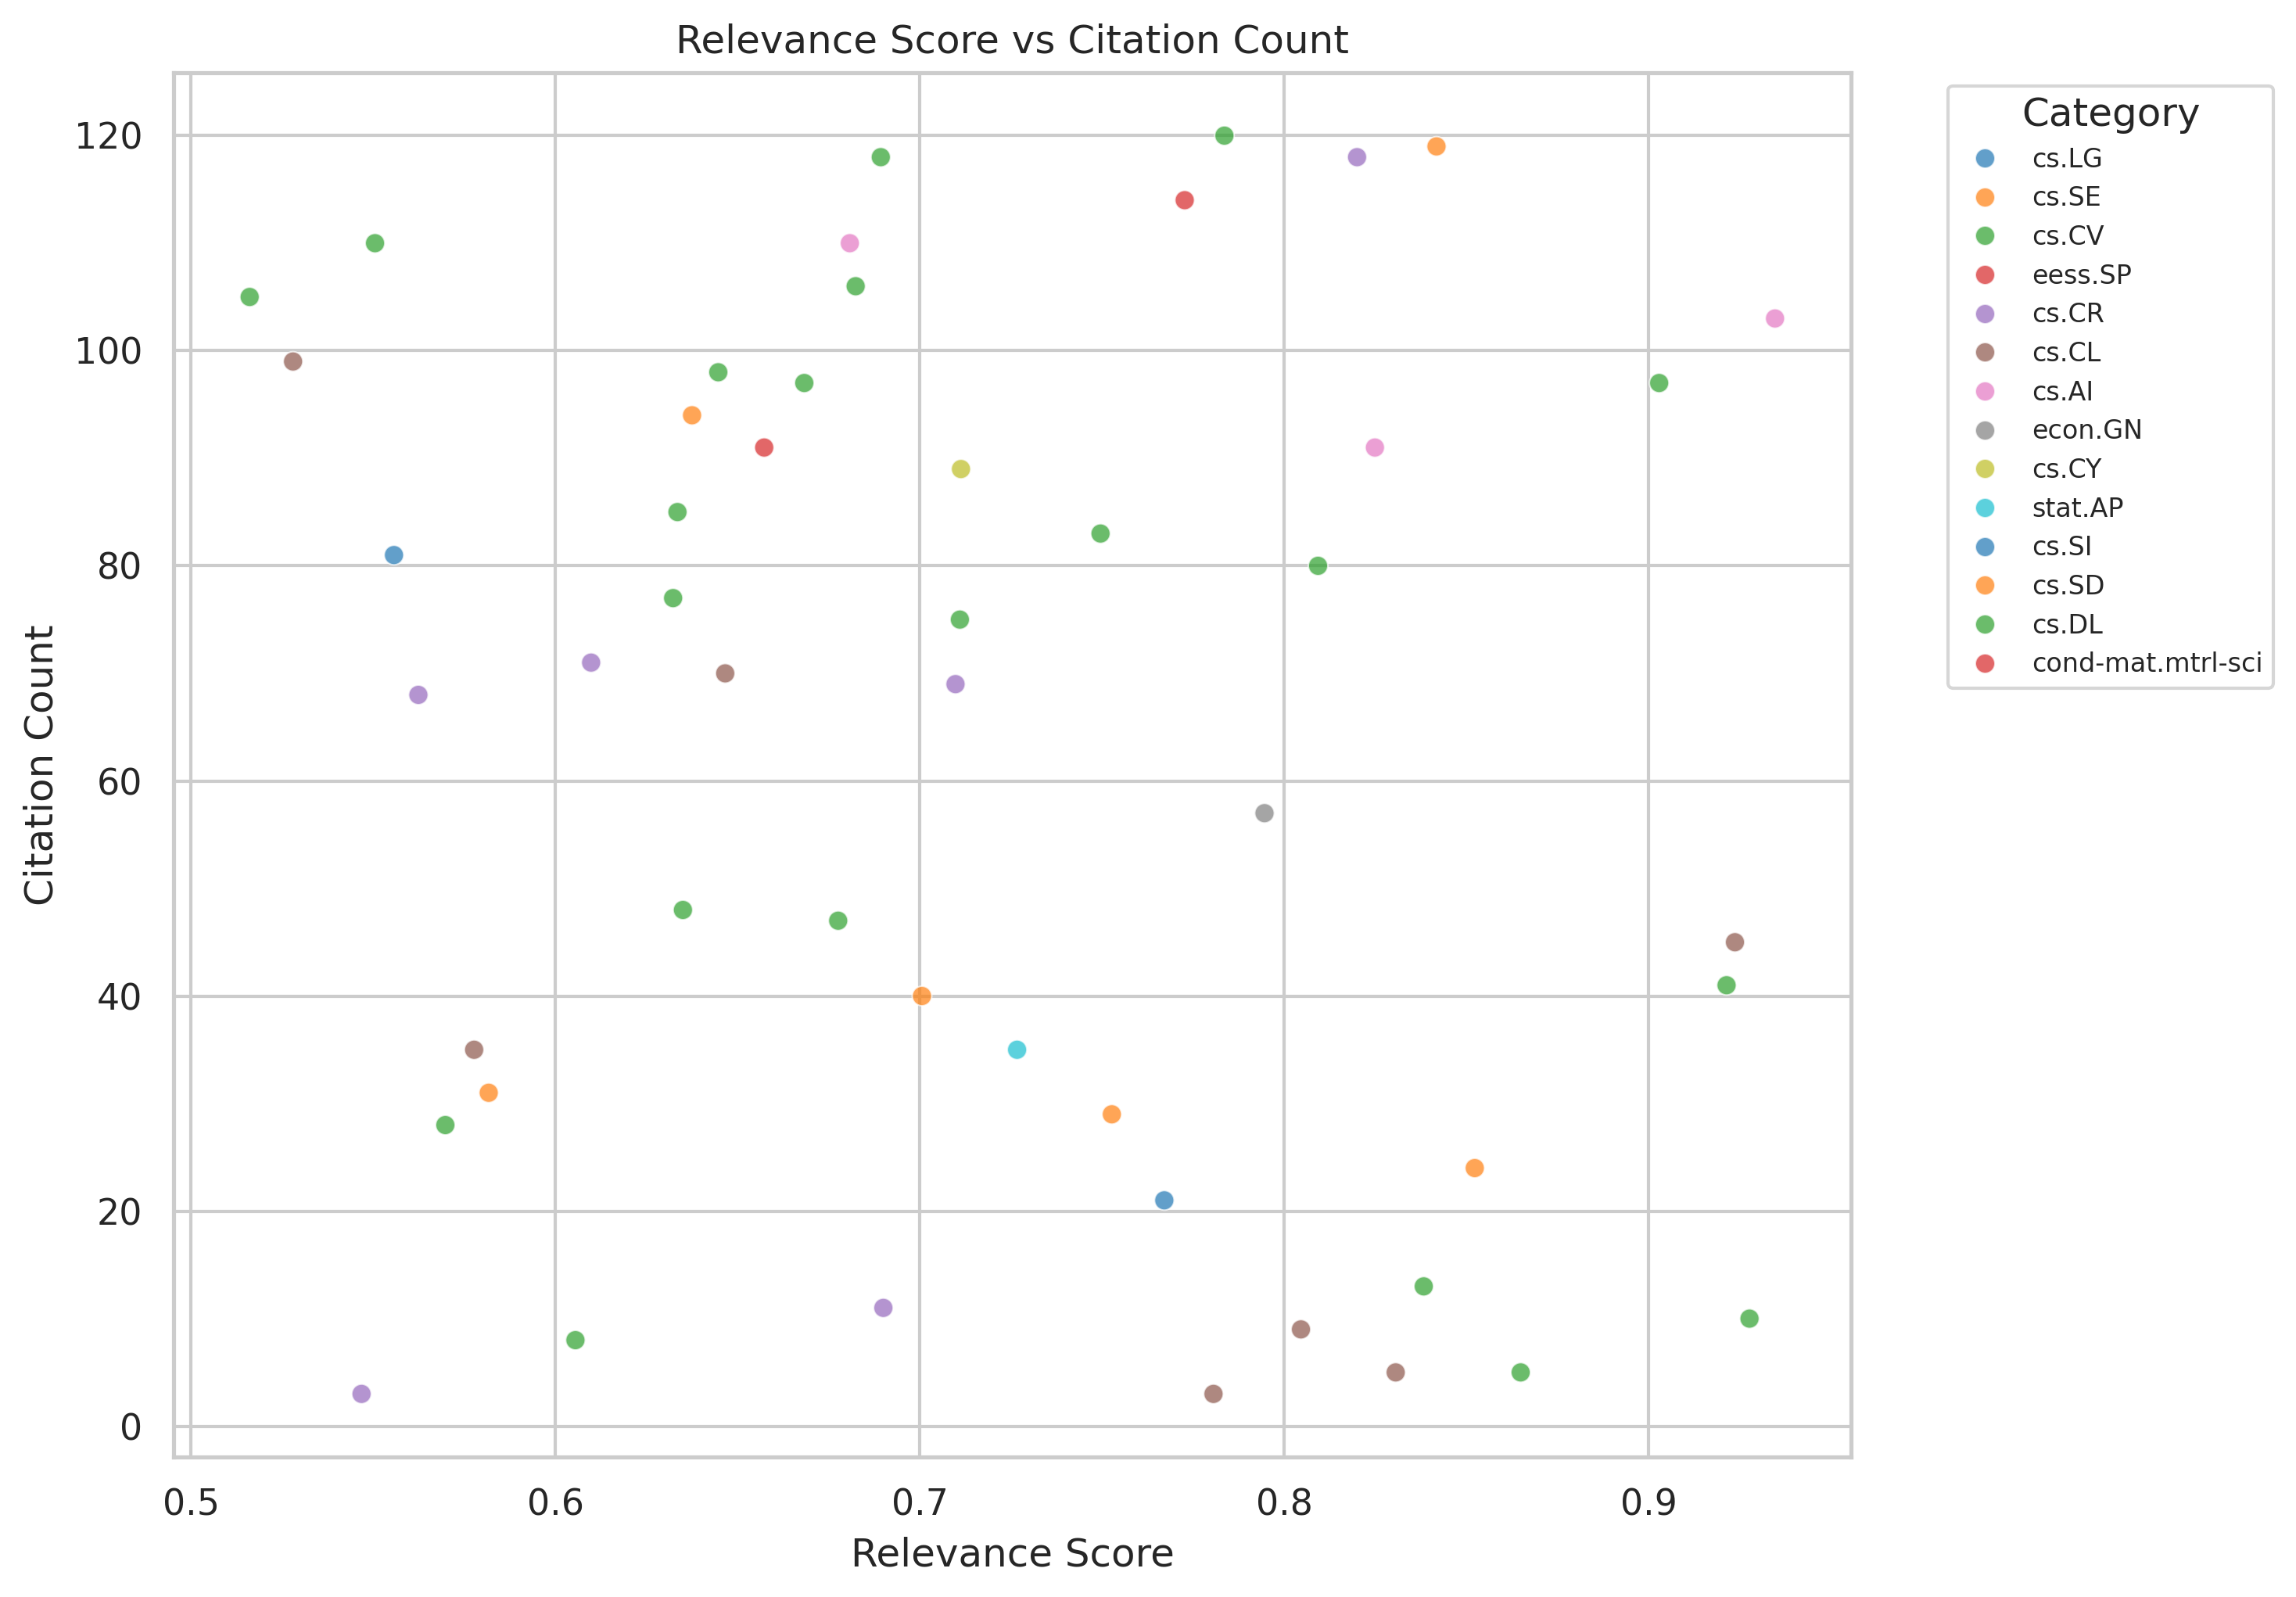

In [9]:
from src.visualization.static_charts import plot_relevance_vs_citations
plot_relevance_vs_citations(df, STATIC_OUT)
Image(str(STATIC_OUT / 'relevance_vs_citations.png'))

**Chart choice:** A scatter plot maps two continuous variables to x/y position — the most
direct encoding for detecting correlation or clustering between relevance score and citation
count. Colour encodes category as a third dimension without adding chartjunk.

### 4.4 Paper Count per Category – Vertical Bar

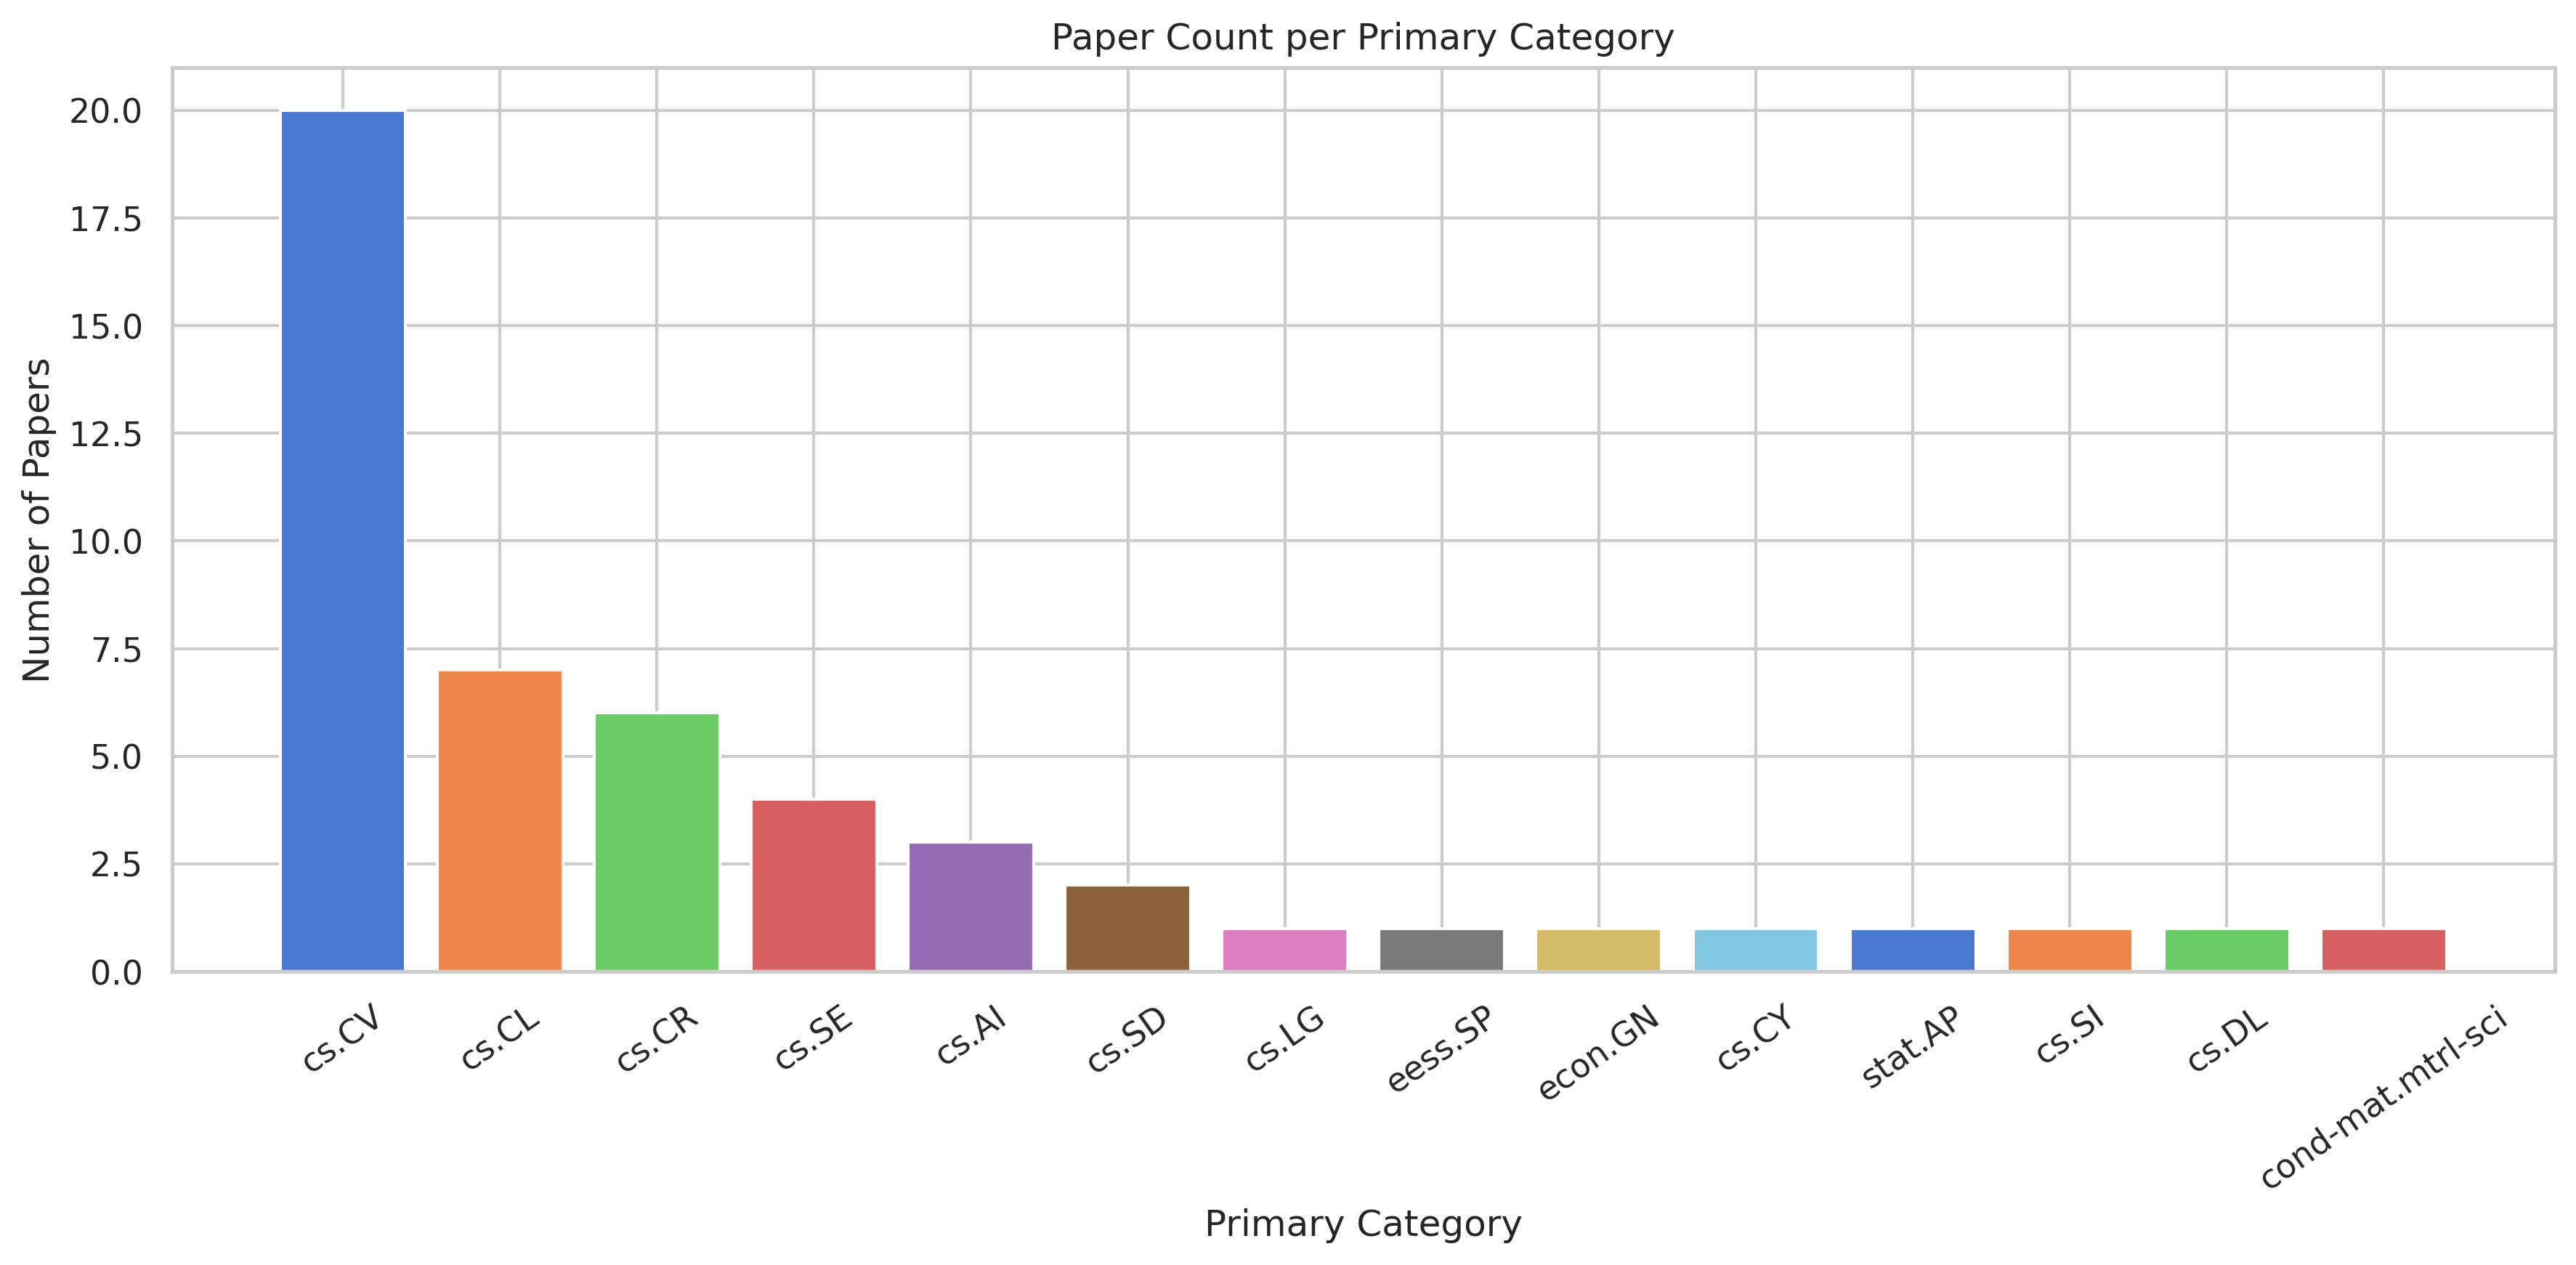

In [10]:
from src.visualization.static_charts import plot_category_paper_count
plot_category_paper_count(df, STATIC_OUT)
Image(str(STATIC_OUT / 'category_paper_count.png'))

**Chart choice:** A vertical bar chart compares discrete categories by a single count metric.
Bar length is a pre-attentive attribute — readers perceive differences instantly without
calculation (Tufte: graphical excellence is that which gives the viewer the most ideas
in the shortest time).

### 4.5 Correlation Heatmap

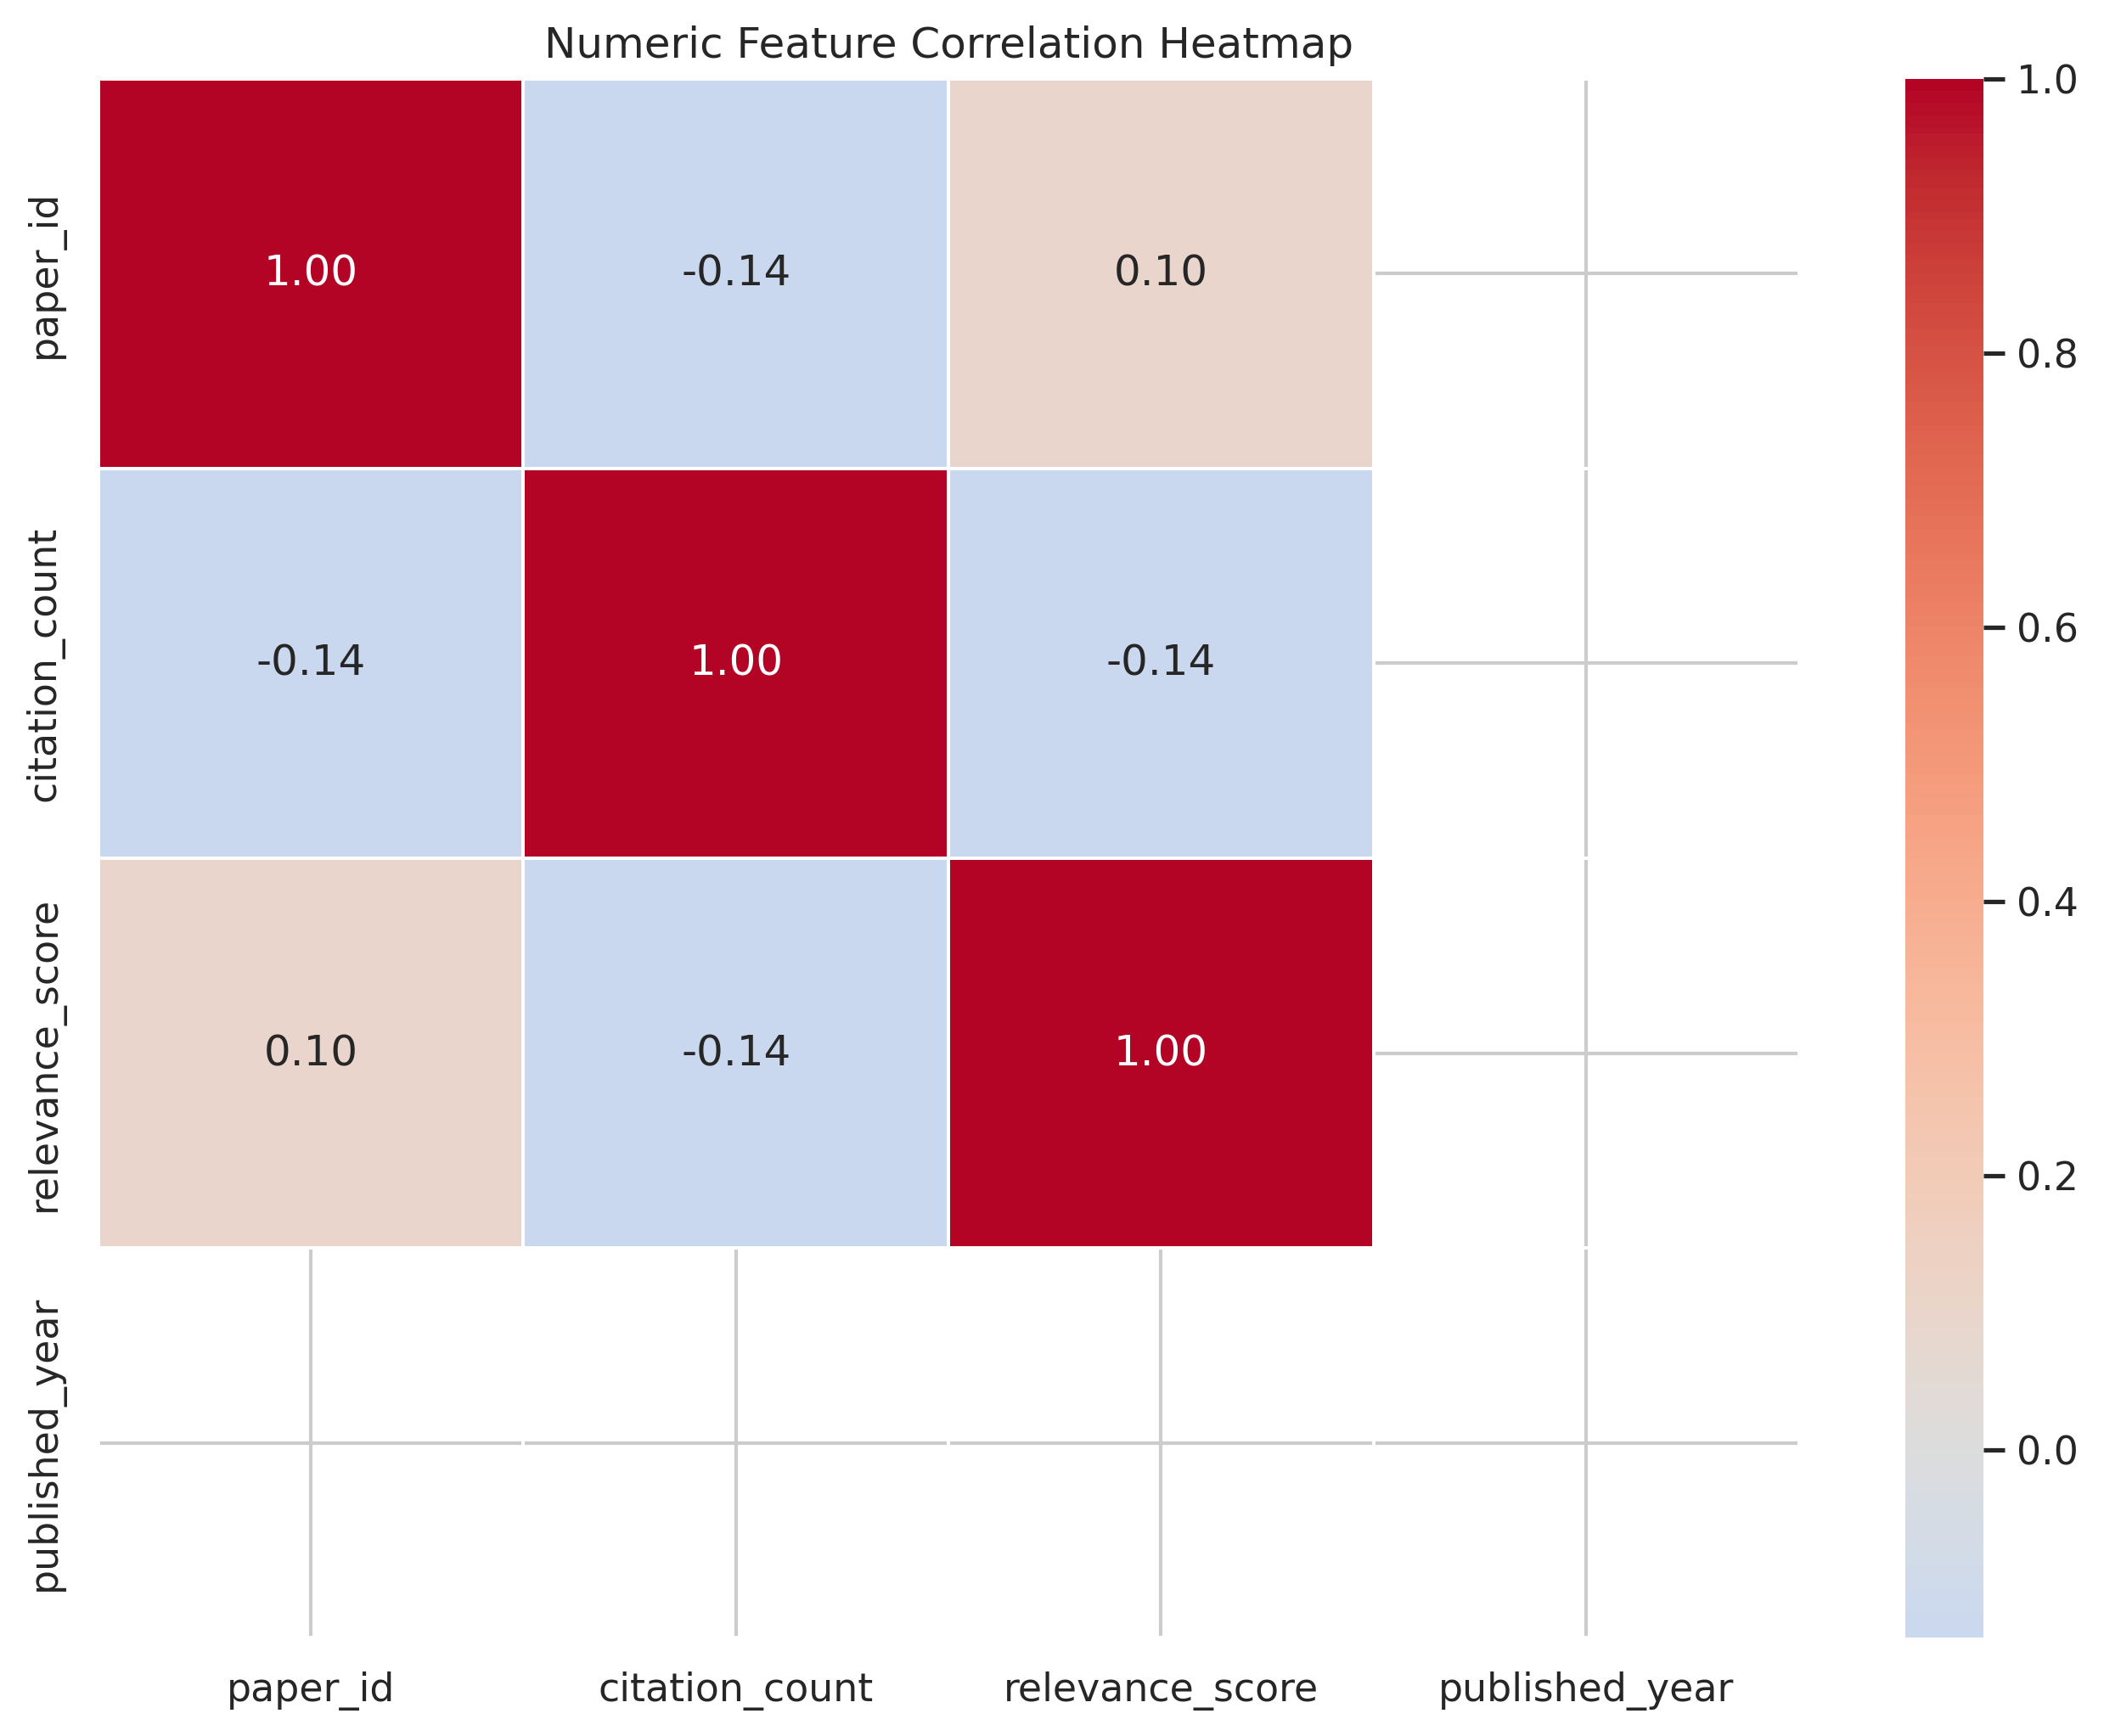

In [11]:
from src.visualization.static_charts import plot_correlation_heatmap
plot_correlation_heatmap(df, STATIC_OUT)
Image(str(STATIC_OUT / 'correlation_heatmap.png'))

**Chart choice:** A heatmap is optimal for a pairwise correlation matrix — colour encodes
a third numeric dimension (correlation strength) in a compact grid. Annotating each cell
with the actual value preserves precision without cluttering the visual field.

---
## Part 5 – Multi-Panel Dashboard Layout

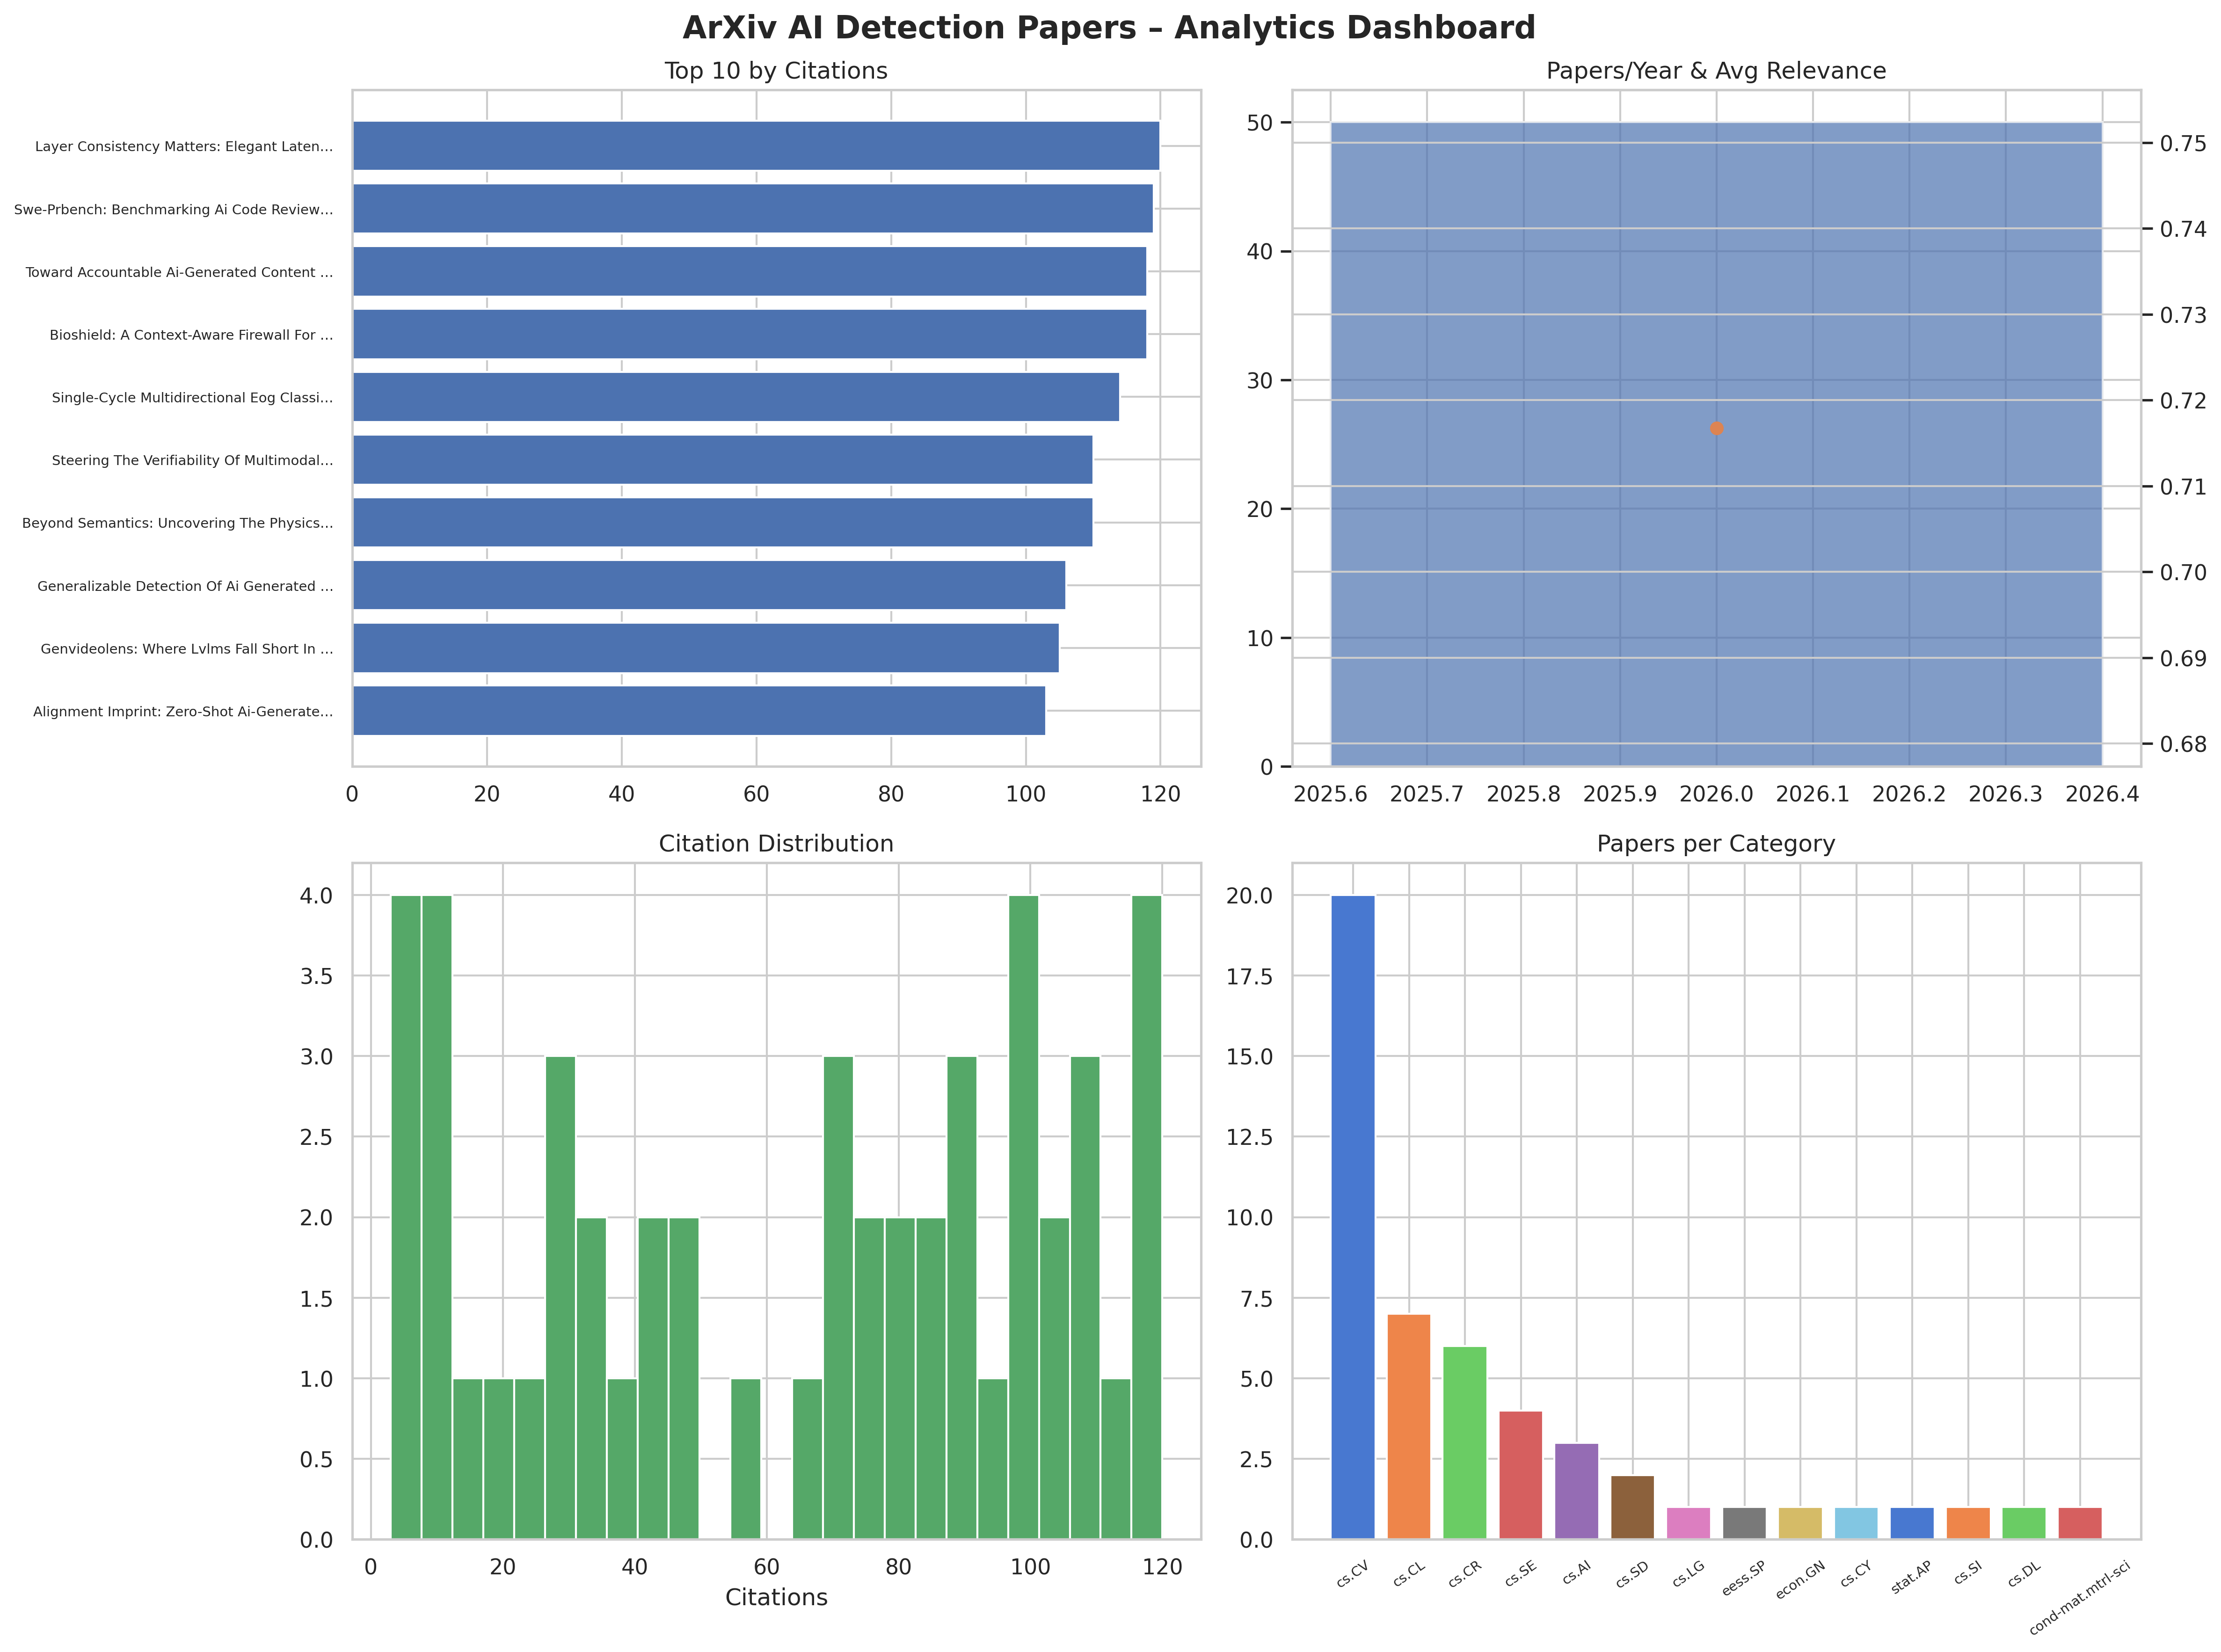

In [12]:
from src.visualization.static_charts import plot_dashboard_subplots
plot_dashboard_subplots(df, STATIC_OUT)
Image(str(STATIC_OUT / 'dashboard_subplots.png'))

**Chart choice:** A 2×2 subplot grid places the four most informative views on a single
canvas, enabling cross-panel comparison without switching figures. `plt.subplots(2, 2)`
keeps the layout explicit and fully addressable by row-column index — standard for
executive-ready dashboards.

---
## Part 6 – Interactive Charts with Plotly Express

In [13]:
from src.visualization.interactive_charts import interactive_citations_scatter
fig = interactive_citations_scatter(df, INTERACTIVE_OUT)
fig.show()

**Chart choice:** An interactive scatter adds hover tooltips (title, category, year, citations)
that would be illegible if printed as static labels. Users can zoom into dense clusters and
identify individual outlier papers by name.

In [14]:
from src.visualization.interactive_charts import interactive_category_bar
fig = interactive_category_bar(df, INTERACTIVE_OUT)
fig.show()

**Chart choice:** Interactive bars let the user hover to see average citations and relevance
per category — metadata that cannot be encoded in bar height without adding a second axis.

In [15]:
from src.visualization.interactive_charts import interactive_yearly_trend
fig = interactive_yearly_trend(df, INTERACTIVE_OUT)
fig.show()

**Chart choice:** An interactive line chart is ideal for time series — users can zoom into
specific year ranges and hover to get exact values without the visual clutter of annotating
every data point.

In [16]:
from src.visualization.interactive_charts import interactive_citation_box
fig = interactive_citation_box(df, INTERACTIVE_OUT)
fig.show()

**Chart choice:** An interactive box plot lets the user hover over individual outlier points
to see the paper title — turning a statistical summary into an exploratory tool.

---
## Part 7 – Interactive Multi-Layout Dashboard

In [17]:
from src.visualization.interactive_charts import interactive_multi_layout
fig = interactive_multi_layout(df, INTERACTIVE_OUT)
fig.show()

**Chart choice:** `make_subplots()` with Graph Objects builds a 2×2 interactive dashboard
where each panel is individually zoomable and hoverable. This is a necessary step up from
Plotly Express when multiple different trace types must share a single figure.

---
## Part 8 – Automated Chart Generation

In [18]:
from src.visualization.chart_generator import generate_all_charts
generate_all_charts(
    data_path='../data/processed/cleaned/cleaned_data.csv',
    static_out='../outputs/visualizations/static',
    interactive_out='../outputs/visualizations/interactive',
)

[chart_generator] Loading data from ../data/processed/cleaned/cleaned_data.csv
[chart_generator] Dataset: 50 rows, 12 columns

── Static charts ──────────────────────────────────
  [1/13] ✓ plot_top10_by_citations
  [2/13] ✓ plot_papers_per_year
  [3/13] ✓ plot_citation_distribution
  [4/13] ✓ plot_citations_by_category
  [5/13] ✓ plot_relevance_vs_citations
  [6/13] ✓ plot_category_paper_count
  [7/13] ✓ plot_correlation_heatmap
  [8/13] ✓ plot_dashboard_subplots

── Interactive charts ─────────────────────────────
  [9/13] ✓ interactive_citations_scatter
  [10/13] ✓ interactive_category_bar
  [11/13] ✓ interactive_yearly_trend
  [12/13] ✓ interactive_citation_box
  [13/13] ✓ interactive_multi_layout

[chart_generator] Done. Static → ../outputs/visualizations/static  Interactive → ../outputs/visualizations/interactive


In [19]:
# Verify output file counts
static_files = list(STATIC_OUT.glob('*'))
interactive_files = list(INTERACTIVE_OUT.glob('*.html'))
print(f'Static files:      {len(static_files)} (expect 16: 8 PNG + 8 PDF)')
print(f'Interactive files: {len(interactive_files)} (expect 5 HTML)')
for f in sorted(static_files): print(' ', f.name)
for f in sorted(interactive_files): print(' ', f.name)

Static files:      16 (expect 16: 8 PNG + 8 PDF)
Interactive files: 5 (expect 5 HTML)
  category_paper_count.pdf
  category_paper_count.png
  citation_distribution.pdf
  citation_distribution.png
  citations_by_category.pdf
  citations_by_category.png
  correlation_heatmap.pdf
  correlation_heatmap.png
  dashboard_subplots.pdf
  dashboard_subplots.png
  papers_per_year.pdf
  papers_per_year.png
  relevance_vs_citations.pdf
  relevance_vs_citations.png
  top10_by_citations.pdf
  top10_by_citations.png
  category_bar.html
  citation_box.html
  citations_scatter.html
  multi_layout_dashboard.html
  yearly_trend.html


---
## Part 10 – Visualization Choices Documentation

### Guiding Principles (Tufte)

Edward Tufte's *The Visual Display of Quantitative Information* establishes three core rules
followed throughout this lab:

1. **Maximize data-ink ratio** — every pixel should encode data. Grid lines are light,
   legends are minimal, backgrounds are white.
2. **Avoid chartjunk** — no 3-D effects, no decorative gradients, no unnecessary borders.
3. **Match chart type to statistical nature of the data.**

### Chart-by-Chart Justification

| Chart | Question answered | Why this type | Key encoding decisions |
|---|---|---|---|
| Top 10 by Citations (horizontal bar) | Which papers have the most impact? | Long categorical labels read L→R naturally; bars rank quantities | Sorted descending; inline annotations remove axis lookup |
| Papers per Year (dual-axis) | Is output volume growing and is quality stable? | Two differently-scaled series share a time axis | Bars for count (discrete), line for mean relevance (continuous) |
| Citation Distribution (histogram) | How are citations distributed — is it power-law? | Single continuous variable → histogram is the canonical choice | KDE overlay shows smoothed density without hiding the raw shape |
| Citations by Category (box plot) | Do certain categories attract more citations? | Box plot compares full distributions across groups | hue= used per seaborn 0.12 API; whiskers show IQR |
| Relevance vs Citations (scatter) | Does higher relevance predict more citations? | Two continuous variables → position on both axes | Colour encodes category as a third channel |
| Category Paper Count (bar) | Which fields are most active in this dataset? | Single count per category → simple vertical bar | Sorted by value_counts(); consistent palette |
| Correlation Heatmap | Which numeric features co-vary? | Pairwise n×n matrix → colour-coded grid is the only compact option | Diverging colormap centred at 0; annotated with 2 dp |
| Dashboard (2×2) | Combined executive overview | Multi-panel avoids context-switching between figures | `plt.subplots(2,2)` with explicit row-col indexing |
| Interactive Scatter | Explore individual outlier papers | Hover reveals title — impossible in static form | 3 hover fields: title, category, year |
| Interactive Bar | Category comparison with metadata | Hover reveals avg citations & relevance per category | Legend toggle lets user isolate one category |
| Interactive Line | Temporal trend exploration | Zoom into specific year windows | 3 hover fields: year, count, avg_citations |
| Interactive Box | Identify outlier papers by name | Hover on outlier point → paper title appears | Top 8 categories to keep the chart readable |
| Interactive Dashboard | Linked multi-view exploration | `make_subplots` + Graph Objects for full control | Each panel individually zoomable; shared color scale |